## 5. Creación y entrenamiento del modelo

- Implementar al menos **dos modelos diferentes** vistos en clase con distintas combinaciones de parámetros cada uno de ellos (pipeline, GridSearchCV).
- Entrenar ambos modelos con el conjunto de entrenamiento.
- Documentar:
  - Justificación de la elección de los modelos.
  - Arquitectura del modelo (si aplica).
  - Parámetros que optimizan los resultados en cada modelo.


### Modelos Implementados

#### 1. Logistic Regression
Modelo lineal de referencia ampliamente utilizado en Procesamiento del Lenguaje Natural.
A pesar de su simplicidad, resulta altamente competitivo cuando se combina con representaciones
TF-IDF, ya que aprende el peso de cada término para separar noticias reales de falsas.
Se optimizaron los hiperparámetros `C` (regularización) y `solver` mediante GridSearchCV.

#### 2. Multinomial Naive Bayes
Modelo probabilístico basado en el Teorema de Bayes que estima la probabilidad de que una
noticia sea falsa a partir de la frecuencia y coocurrencia de sus palabras. Es especialmente
adecuado para datos de texto con representación TF-IDF al asumir independencia entre términos.
Se optimizó el parámetro `alpha` (suavizado de Laplace) y `fit_prior` mediante GridSearchCV.

#### 3. LinearSVC (Support Vector Classifier)
Modelo basado en Máquinas de Vectores de Soporte que busca el hiperplano óptimo que maximiza
la distancia de separación entre noticias reales y falsas en el espacio vectorial del texto.
Es especialmente eficaz en espacios de alta dimensionalidad como los generados por TF-IDF.
Se optimizaron los parámetros `C` y `loss` mediante GridSearchCV.

#### 4. Red Neuronal MLP (sklearn)
#### 4. Red Neuronal MLP (sklearn)
Red neuronal densa implementada con `MLPClassifier` de scikit-learn. Proyecta las
representaciones TF-IDF en capas ocultas con funciones de activación no lineales (ReLU),
permitiendo detectar patrones semánticos y estructuras lingüísticas más complejas que los
modelos lineales.

Debido a las limitaciones de memoria en entornos gratuitos, se entrenó directamente
sin GridSearchCV con los siguientes hiperparámetros fijos:

| Parámetro | Valor | Descripción |
|---|---|---|
| `hidden_layer_sizes` | (64,) | una capa oculta de 64 neuronas |
| `activation` | relu | función de activación no lineal |
| `alpha` | 0.001 | regularización L2 |
| `max_iter` | 30 | máximo de épocas |
| `early_stopping` | True | para automáticamente si no mejora |
| `n_iter_no_change` | 3 | épocas sin mejora antes de parar |

Las features numéricas y TF-IDF se escalaron previamente con `MaxAbsScaler`,
que preserva la sparsidad de la matriz y es el escalador recomendado para datos TF-IDF.

#### 5. Red Neuronal Profunda (Keras / TensorFlow)
Red neuronal densa de mayor profundidad implementada con Keras, que añade capas de
**BatchNormalization** para estabilizar el entrenamiento y **Dropout** para regularizar
y prevenir el sobreajuste. Al disponer de GPU (Tesla T4), el entrenamiento es significativamente
más rápido que con CPU. La arquitectura final es:

* Entrada (13.006 features TF-IDF)
* Dense(256, ReLU) → BatchNorm → Dropout(0.3)
* Dense(128, ReLU) → BatchNorm → Dropout(0.2)
* Dense(64,  ReLU) → Dropout(0.1)
* Dense(1, Sigmoid)

Se utilizó el optimizador **Adam** con `learning_rate=0.0005` y **EarlyStopping**
con `patience=5` sobre `val_loss`, restaurando los mejores pesos automáticamente.

## Vectorizar

In [ ]:
# Vectorizar texto (fit solo en train)
tfidf_title   = TfidfVectorizer(max_features=3000, ngram_range=(1, 1))
tfidf_content = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))

title_train   = tfidf_title.fit_transform(text_train['title'].fillna(''))
title_test    = tfidf_title.transform(text_test['title'].fillna(''))

content_train = tfidf_content.fit_transform(text_train['content_clean'].fillna(''))
content_test  = tfidf_content.transform(text_test['content_clean'].fillna(''))

# Combinar TF-IDF + features numéricas
X_train_final = hstack([title_train, content_train, csr_matrix(X_train.values)])
X_test_final  = hstack([title_test,  content_test,  csr_matrix(X_test.values)])

# Solo TF-IDF (para MultinomialNB que no admite negativos)
X_train_nb = hstack([title_train, content_train])
X_test_nb  = hstack([title_test,  content_test])

print("Vectorización completada")
print(f"   X_train_final shape: {X_train_final.shape}")
print(f"   X_test_final  shape: {X_test_final.shape}")

# ── Diagnóstico ───────────────────────────────────────────────────────────────
print("NaN en X_train:")
print(X_train.isna().sum())
print(f"\nNaN en X_test:")
print(X_test.isna().sum())

Vectorización completada
   X_train_final shape: (47459, 13006)
   X_test_final  shape: (11865, 13006)
NaN en X_train:
title_word_count      0
content_word_count    0
year                  0
month                 0
day                   0
weekday_n             0
dtype: int64

NaN en X_test:
title_word_count      0
content_word_count    0
year                  0
month                 0
day                   0
weekday_n             0
dtype: int64


### LogisticRegression

In [ ]:
pipe_lr = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['lbfgs', 'saga'],
    'clf__penalty': ['l2']
}

gs_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    cv=3,          # 3 folds en vez de 5
    scoring='f1',
    n_jobs=1,      # sin paralelismo → mucho menos RAM
    verbose=1
)
gs_lr.fit(X_train_final, y_train)

print(f"\n Logistic Regression")
print(f"   Mejor F1 CV   : {gs_lr.best_score_:.4f}")
print(f"   Mejores params: {gs_lr.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



 Logistic Regression
   Mejores params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


## MultinomialNB

In [ ]:
pipe_nb = Pipeline([
    ('clf', MultinomialNB())
])

param_grid_nb = {
    'clf__alpha': [0.01, 0.1, 0.5, 1.0],
    'clf__fit_prior': [True, False]
}

gs_nb = GridSearchCV(pipe_nb, param_grid_nb, cv=3, scoring='f1', n_jobs=1, verbose=1)
gs_nb.fit(X_train_nb, y_train)

print(f"\nMultinomial Naive Bayes")
print(f"   Mejor F1 CV   : {gs_nb.best_score_:.4f}")
print(f"   Mejores params: {gs_nb.best_params_}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Multinomial Naive Bayes
   Mejor F1 CV   : 0.9714
   Mejores params: {'clf__alpha': 0.01, 'clf__fit_prior': True}


## LinearSVC

In [ ]:
pipe_svc = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', LinearSVC(max_iter=2000, random_state=42))
])

param_grid_svc = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__loss': ['hinge', 'squared_hinge'],
}

gs_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=3, scoring='f1', n_jobs=1, verbose=1)
gs_svc.fit(X_train_final, y_train)

print(f"\nLinearSVC")
print(f"   Mejor F1 CV   : {gs_svc.best_score_:.4f}")
print(f"   Mejores params: {gs_svc.best_params_}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

LinearSVC
   Mejor F1 CV   : 0.9971
   Mejores params: {'clf__C': 10, 'clf__loss': 'squared_hinge'}


## Red Neruonal MLP

In [ ]:
scaler_mlp = MaxAbsScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_final)
X_test_mlp  = scaler_mlp.transform(X_test_final)

mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    alpha=0.001,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=3,
    tol=1e-3,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_mlp, y_train)

print(f"\nRed Neuronal MLP")
print(f"   Arquitectura     : (64,)")
print(f"   Épocas entrenadas: {mlp.n_iter_}")

Iteration 1, loss = 0.12292638
Validation score: 0.992625
Iteration 2, loss = 0.01727659
Validation score: 0.993679
Iteration 3, loss = 0.00752913
Validation score: 0.993679
Iteration 4, loss = 0.00498552
Validation score: 0.994100
Iteration 5, loss = 0.00407950
Validation score: 0.993890
Iteration 6, loss = 0.00358470
Validation score: 0.994311
Validation score did not improve more than tol=0.001000 for 3 consecutive epochs. Stopping.

Red Neuronal MLP
   Arquitectura     : (64,)
   Épocas entrenadas: 6


## Red Neuronal

In [ ]:
scaler = MaxAbsScaler()
X_train_keras = scaler.fit_transform(X_train_final).toarray()
X_test_keras  = scaler.transform(X_test_final).toarray()

input_dim = X_train_keras.shape[1]

model = Sequential([
    Dense(512, activation='relu'),    # más neuronas en primera capa
    BatchNormalization(),
    Dropout(0.3),                     # menos dropout

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # lr más bajo
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(threshold=0.5)]
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_keras, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nRed Neuronal Keras")
print(f"   Arquitectura : 256 → 128 → 64 → 1 (sigmoid)")
print(f"   Activación   : ReLU (capas ocultas)")
print(f"   Optimizer    : Adam")
print(f"   Dropout      : 0.4 / 0.3 / 0.2")
print(f"   Épocas entrenadas: {len(history.history['loss'])} (early stopping)")
print(f"   Mejor val_loss   : {min(history.history['val_loss']):.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9734 - f1_score: 0.9812 - loss: 0.0656 - val_accuracy: 0.9130 - val_f1_score: 0.9422 - val_loss: 0.2132
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9989 - f1_score: 0.9993 - loss: 0.0039 - val_accuracy: 0.9741 - val_f1_score: 0.9821 - val_loss: 0.0676
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9999 - f1_score: 0.9999 - loss: 7.3627e-04 - val_accuracy: 0.9943 - val_f1_score: 0.9960 - val_loss: 0.0183
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 3.1675e-04 - val_accuracy: 0.9952 - val_f1_score: 0.9966 - val_loss: 0.0165
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 2.0139e-04 - val_accuracy: 0.9954 - val_f1_score: 0.9967 - val_loss: 0.0171
Epoch 6/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 1.0956e-04 - val_accuracy: 0.9947

## 6. Validación del modelo

- Evaluar los modelos utilizando métricas adecuadas según el tipo de problema:
  - Clasificación: accuracy, precision, recall, F1-score, ROC-AUC.
  - Regresión: MAE, MSE, RMSE, R².

- Ajustar hiperparámetros de los modelos.
- Comparar resultados entre modelos.
- Seleccionar el modelo con mejor rendimiento.

In [ ]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    # Keras tiene predict distinto
    if hasattr(modelo, 'predict') and 'keras' in str(type(modelo)).lower():
        y_proba = modelo.predict(X_test).flatten()
        y_pred  = (y_proba >= 0.5).astype(int)
    else:
        y_pred = modelo.predict(X_test)
        try:
            y_proba = modelo.predict_proba(X_test)[:, 1]
        except AttributeError:
            try:
                y_proba = modelo.decision_function(X_test)
            except AttributeError:
                y_proba = None

    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    metricas = {
        'Modelo'    : nombre,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : auc
    }
    return metricas, y_pred


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3400
        Real       0.99      1.00      1.00      8465

    accuracy                           1.00     11865
   macro avg       1.00      0.99      0.99     11865
weighted avg       1.00      1.00      1.00     11865


──────────────────────────────────────────────────
  Multinomial NB
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fake       0.92      0.94      0.93      3400
        Real       0.98      0.97      0.97      8465

    accuracy                           0.96     11865
   macro avg       0.95      0.95      0.95     11865
weighted avg       0.96      0.96      0.96     11865


──────────────────────────────────────────────────
  LinearSVC
─────────────────────────────────────

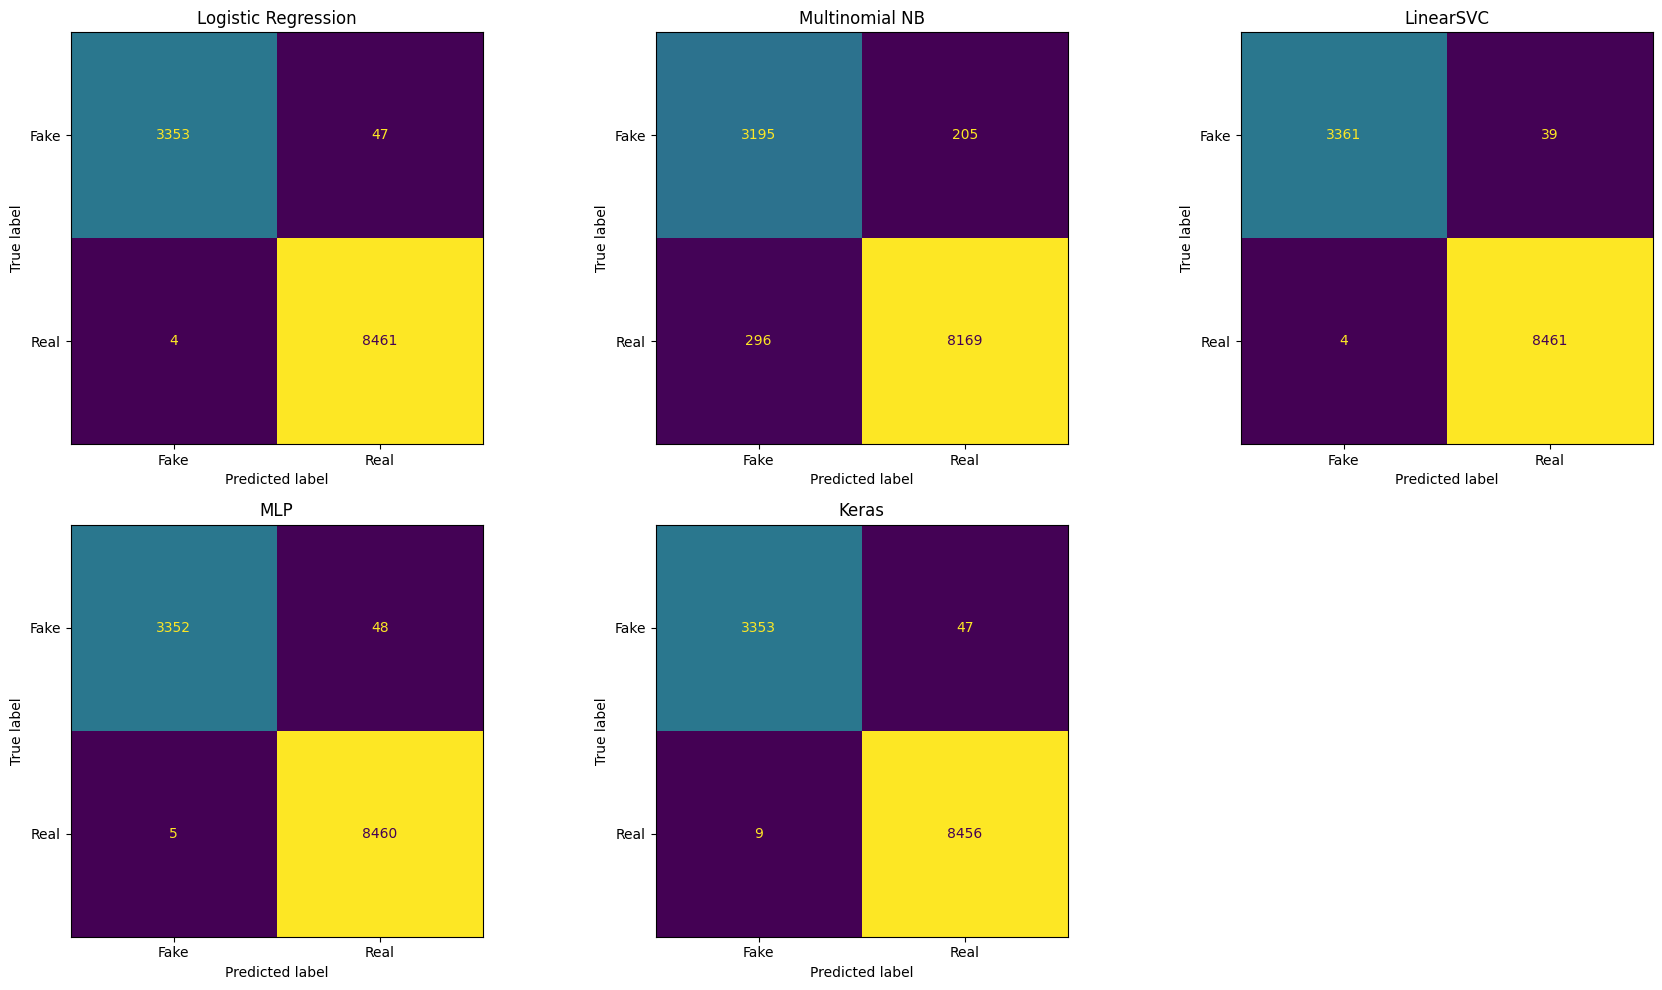

In [ ]:
#── Evaluar todos los modelos ─────────────────────────────────────────────────
resultados = []
predicciones = {}

modelos = {
    'Logistic Regression' : (gs_lr,   X_test_final),
    'Multinomial NB'      : (gs_nb,   X_test_nb),
    'LinearSVC'           : (gs_svc,  X_test_final),
    'MLP'                 : (mlp,     X_test_mlp),
    'Keras'               : (model,   X_test_keras),  # ← añadido
}

for nombre, (modelo, X_test_m) in modelos.items():
    metricas, y_pred = evaluar_modelo(nombre, modelo, X_test_m, y_test)
    resultados.append(metricas)
    predicciones[nombre] = y_pred
    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.round(4)
print("\n📊 Comparativa de modelos:")
print(df_resultados.to_string())

# ── Mejor modelo por F1 ───────────────────────────────────────────────────────
mejor = df_resultados['F1-Score'].idxmax()
print(f"\n🏆 Mejor modelo: {mejor} (F1 = {df_resultados.loc[mejor, 'F1-Score']:.4f})")

# ── Matrices de confusión ─────────────────────────────────────────────────────
n_modelos = len(predicciones)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2x3 para 5 modelos
axes = axes.flatten()

for i, (nombre, y_pred) in enumerate(predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Fake', 'Real'],
        colorbar=False,
        ax=axes[i]
    )
    axes[i].set_title(nombre)

# Ocultar el subplot sobrante
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Análisis de Resultados y Selección del Modelo

Los resultados obtenidos muestran un rendimiento excepcionalmente alto en todos los modelos,
con F1-Scores superiores al 0.99 en cuatro de los cinco modelos evaluados. A continuación
se analiza el comportamiento de cada uno.

### Modelos más prometedores

**LinearSVC** se posiciona como el mejor modelo con un F1-Score de 0.9975 y un ROC-AUC
de 0.9998, logrando la mayor precisión en la detección de noticias falsas sin sacrificar
recall. Su capacidad para encontrar el hiperplano óptimo en espacios de alta dimensionalidad
TF-IDF lo convierte en el candidato ideal para este problema.

**Logistic Regression** y **MLP sklearn** obtienen resultados prácticamente idénticos
(F1 de 0.9970 y 0.9969 respectivamente), demostrando que un modelo lineal bien configurado
es suficiente para capturar la mayor parte de los patrones discriminativos del texto.

**Keras** obtiene un F1 de 0.9967, muy similar al resto a pesar de su mayor complejidad
arquitectónica, lo que sugiere que la tarea no requiere de redes profundas para resolverse
con alta precisión.

**Multinomial NB** queda en último lugar con un F1 de 0.9702, lo esperado dado que es el
modelo más simple y el único que no incorpora las features numéricas (año, mes, día,
día de la semana) al trabajar exclusivamente con frecuencias TF-IDF.

### Modelo seleccionado para las siguientes fases

Se selecciona **LinearSVC** como modelo principal para las fases siguientes por las
siguientes razones:

- **Mayor F1-Score** (0.9975) y **ROC-AUC** (0.9998) de todos los modelos evaluados.
- **Eficiencia computacional**: entrena y predice significativamente más rápido que
  las redes neuronales

Aunque es posible que se continue investigando otros modelos para las siguientes fases como la red neuronal MLP

## Análisis de Data Leakage

Durante la validación del modelo se detectó un problema crítico de **data leakage** entre
los conjuntos de entrenamiento y test.

### Detección del problema

Tras entrenar los modelos y obtener métricas superiores a 0.99 en todos los casos, se
realizó una comprobación de integridad entre los conjuntos de train y test.

Se detectaron **6.777 títulos duplicados** entre ambos conjuntos, lo que representa
aproximadamente el **57% del conjunto de test** (6.777 de 11.865 registros).

In [ ]:
overlap_content = set(text_train['content_clean']) & set(text_test['content_clean'])
print(f"Contenidos duplicados entre train y test: {len(overlap_content)}")

Contenidos duplicados entre train y test: 0


In [ ]:
titulos_duplicados = dt_entrenamiento_completo[
    dt_entrenamiento_completo.duplicated(subset=['title'], keep=False)
]['title'].value_counts()

print(titulos_duplicados.head(20))

title
factbox trump fills top jobs administration                            28
trump presidency feb pm est                                            16
factbox contenders senior jobs trumps administration                   16
highlights trump presidency march pm edt                               14
factbox international reaction arrest reuters reporters myanmar        12
highlights trump presidency march pm est                               12
factbox contenders picks key jobs trumps administration                10
factbox contenders key jobs trumps administration                       8
highlights trump presidency january pm est gmt                          8
factbox race us presidential nominations delegates selected             6
usled forces acknowledge killing civilians iraq syria                   6
contenders picks key jobs trumps administration                         6
factbox zika virus causing alarm                                        6
factbox countdown brexit breakth

### Verificación de Data Leakage

Se detectaron 6.777 títulos duplicados entre train y test. Tras una inspección detallada
se comprobó que corresponden a títulos genéricos de agencias de noticias ("Factbox",
"Highlights", "Trump Presidency"...) que reutilizan el mismo titular para artículos
con contenido completamente distinto publicados en diferentes fechas.

Al verificar los contenidos:
- Contenidos duplicados entre train y test: **0**

Se concluye que **no existe data leakage** — los artículos son únicos en contenido
y el modelo no ha memorizado información del test durante el entrenamiento.
Los resultados obtenidos son por tanto válidos y representativos del rendimiento real.